### Imports

In [2]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, SpectralEmbedding # For Laplacian Eigenmaps
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)


### Load data

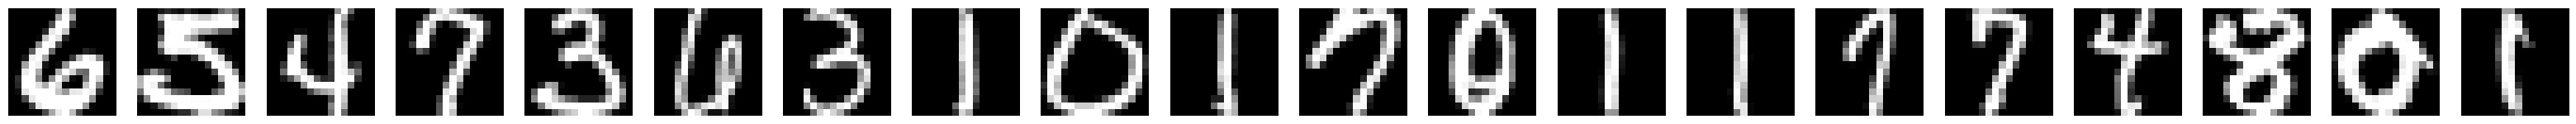

In [9]:
selected_digits = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

def load_digits_data(selected_digits):

    # Load the digits dataset
    digits = np.load('data/digits.npy')

    # Split into features and labels
    X, y = digits[:, :-1].astype(np.float32), digits[:, -1].astype(np.int64) # All rows, but not the last column

    # Filter for selected digits
    mask = np.isin(y, selected_digits)
    
    X, y = X[mask], y[mask]
    return X, y

X, y = load_digits_data(selected_digits)

fig, axes = plt.subplots(nrows=1, ncols=20, figsize=(40, 4))
for i in range(20):
    axes[i].imshow(X[i].reshape(16, 16), cmap='gray')
    axes[i].axis('off')
plt.show()

In [ ]:
#from src.demo_project.data import get_dataloaders

trainloader, testloader = get_dataloaders
(batch_size=32)


In [24]:
len(next(iter(trainloader)))

2

### Autoencoder

In [28]:
torch.manual_seed(42)
import torch
import torch.nn as nn
import torch.optim as optim


class MnistAutoencoder(nn.Module):
        
    def __init__(self, latent_dim=2):
        super().__init__()

        # ----- ENCODER -----
        self.encoder = nn.Sequential(
            nn.Linear(256, 256),
            nn.LeakyReLU(0.02),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.02),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.02),

            nn.Linear(64, latent_dim),
        )

        # ----- DECODER -----
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.02),

            nn.Linear(64, 128),
            nn.LeakyReLU(0.02),

            nn.Linear(128, 256),
            nn.LeakyReLU(0.02),  
            
            nn.Linear(256, 256),
            nn.Tanh()  # inputs are in [-1, 1]
        )    

    def forward(self,x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z # z is latent space

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
epochs = 200
model = MnistAutoencoder(latent_dim=2).to(device)
criterion = nn.MSELoss(reduction='mean')
lambda_l2 = 0.5 
lambda_opt_wd = 1e-8

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=lambda_opt_wd)

train_losses = []

def train_model(train_dataloader, model, epochs, criterion, optimizer, device):

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for imgs, _ in train_dataloader:
            imgs = imgs.to(device)
            optimizer.zero_grad()

            # forward pass
            outputs, z = model(imgs)            
            # reconstruction loss
            recon_loss = criterion(outputs, imgs)
            
            # Explicit latent L2 regularization: ||z||^2
            latent_l2 = z.pow(2).sum(dim=1).mean()

            # total loss
            loss = recon_loss + lambda_l2 * latent_l2

            # backward
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * imgs.size(0)
        
        train_losses.append(total_train_loss / len(train_dataloader.dataset))

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} = {recon_loss} + {lambda_l2}*{latent_l2}")

    return model, train_losses

# Train the model
model, train_losses = train_model(trainloader, model, epochs, criterion, optimizer, device)

#trainloader, testloader
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()

NameError: name 'train_dataloader' is not defined

### Helper functions


In [4]:

# Helper functions
def gauss_2d(centroid, ccov, std=2, points=100):
    """
    Returns two vectors representing slice through gaussian, cut at given standard deviation.

    Parameters:
    centroid (array-like): The centroid of the Gaussian distribution.
    ccov (array-like): The covariance matrix of the Gaussian distribution.
    std (float, optional): The standard deviation at which to cut the Gaussian distribution. Default is 2.
    points (int, optional): The number of points to sample along the slice. Default is 100.

    Returns:
    tuple: A tuple containing two vectors representing the slice through the Gaussian distribution.
    """
    mean = np.c_[centroid]
    tt = np.c_[np.linspace(0, 2 * np.pi, points)]
    x = np.cos(tt)
    y = np.sin(tt)
    ap = np.concatenate((x, y), axis=1).T
    d, v = np.linalg.eig(ccov)
    d = std * np.sqrt(np.diag(d))
    bp = np.dot(v, np.dot(d, ap)) + np.tile(mean, (1, ap.shape[1]))
    return bp[0, :], bp[1, :]

def clusterplot(X, clusterid=None, centroids=None, y=None, covariances=None):
    
    if clusterid is not None:
        for i, pred_class in enumerate(np.unique(clusterid)):
            mask = (clusterid == pred_class)
            plt.scatter(X[mask, 0], X[mask, 1], s=100, facecolors=f'C{i}', label=f'Predicted class {pred_class}', linewidth=5)

    for i, true_class in enumerate(np.unique(y)):
        mask = (y == true_class)
        plt.scatter(X[mask, 0], X[mask, 1], s=50, c=f"C{i}", edgecolors='k', label=f'True class {true_class}')

    if centroids is not None:
        plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='X')

    if covariances is not None:
        for i in range(len(centroids)):
            x1, x2 = gauss_2d(centroids[i], covariances[i])
            plt.plot(x1, x2, "-", color=f'C{i}', linewidth=3)

    plt.title("Cluster Plot")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(ncols=2)

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def plot_representation_w_imgs(X_rep, X_imgs, labels, selected_digits, zoom=0.6):
    # Make a figure
    fig, ax = plt.subplots(figsize=(10, 6))
    # Compute true min/max of the latent space
    x_min, x_max = X_rep[:,0].min(), X_rep[:,0].max()
    y_min, y_max = X_rep[:,1].min(), X_rep[:,1].max()
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    for digit in selected_digits:
        mask = (labels == digit)
        xs = X_rep[mask][:, 0]
        ys = X_rep[mask][:, 1]
        imgs = X_imgs[mask]

        for x, y, img in zip(xs, ys, imgs):
            thumbnail = img.reshape(16, 16)
            imagebox = OffsetImage(thumbnail, cmap="gray_r", zoom=zoom)

            # place it at (x,y)
            ab = AnnotationBbox(imagebox, (x, y), frameon=False)
            ax.add_artist(ab)

    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.title("Representations with images")
    plt.show()
    plt.close()    

In [13]:
import jax.numpy as jnp
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import equinox as eqx
import jax
import jax.numpy as jnp
import optax  # https://github.com/deepmind/optax
import torch  # https://pytorch.org
import torchvision  # https://pytorch.org



def numpy_collate(batch):
    """Converts a batch of torch tensors to jax numpy arrays."""
    if isinstance(batch[0], (list, tuple)):
        return [numpy_collate(samples) for samples in zip(*batch)]
    return jnp.array(batch)


def get_dataloaders(batch_size=64):
    normalise_data = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize((0.5,), (0.5,)),
        ]
    )
    train_dataset = torchvision.datasets.MNIST(
        root="data",
        train=True,
        download=True,
        transform=normalise_data,
    )
    test_dataset = torchvision.datasets.MNIST(
        root="data",
        train=False,
        download=True,
        transform=normalise_data,
    )
    trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    return trainloader, testloader


"""

    training_data = datasets.MNIST(
        root="data", train=True, download=True, transform=transforms.ToTensor()
    )
    test_data = datasets.MNIST(
        root="data", train=False, download=True, transform=transforms.ToTensor()
    )

    train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True, collate_fn=numpy_collate)

    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=numpy_collate)
    
    return train_loader, test_loader

    """


'\n\n    training_data = datasets.MNIST(\n        root="data", train=True, download=True, transform=transforms.ToTensor()\n    )\n    test_data = datasets.MNIST(\n        root="data", train=False, download=True, transform=transforms.ToTensor()\n    )\n\n    train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True, collate_fn=numpy_collate)\n\n    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=numpy_collate)\n\n    return train_loader, test_loader\n\n    '